In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
df = pd.read_csv("student_performance.csv")
df.head()

,Student_Name,Student_ID,Study_Hours,Attendance,Assignment_Score,Exam_Score
0,Hareem,S001,1.6,92,98,64
1,Safi,S002,4.1,74,70,79
2,Rameen,S003,1.8,95,70,60
3,Zainab,S004,3.9,76,63,91
4,Roha,S005,6.4,63,89,88


In [4]:
mean = df["Exam_Score"].mean()
median = df["Exam_Score"].median()
mode = df["Exam_Score"].mode()[0]
variance = df["Exam_Score"].var()
std_dev = df["Exam_Score"].std()

print(f"Mean: {mean:.2f}")
print(f"Median: {median}")
print(f"Mode: {mode}")
print(f"Variance: {variance:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")

print("\nInterpretation:")
print(f"- Average exam score is {mean:.2f}.")
print(f"- Half of the students scored above {median} and half below.")
print(f"- The most common score is {mode}.")
print(f"- Standard deviation of {std_dev:.2f} indicates a moderate spread of scores.")

Mean: 72.35
Median: 68.0
Mode: 65
Variance: 295.29
Standard Deviation: 17.18

Interpretation:
- Average exam score is 72.35.
- Half of the students scored above 68.0 and half below.
- The most common score is 65.
- Standard deviation of 17.18 indicates a moderate spread of scores.


In [5]:
Q1 = df["Exam_Score"].quantile(0.25)
Q2 = df["Exam_Score"].quantile(0.50)
Q3 = df["Exam_Score"].quantile(0.75)

minimum = df["Exam_Score"].min()
maximum = df["Exam_Score"].max()

print(f"25th Percentile (Q1): {Q1}")
print(f"50th Percentile (Median): {Q2}")
print(f"75th Percentile (Q3): {Q3}")
print(f"Minimum Score: {minimum}")
print(f"Maximum Score: {maximum}")

print(f"\nMiddle 50% of students scored between {Q1} and {Q3}.")

25th Percentile (Q1): 59.0
50th Percentile (Median): 68.0
75th Percentile (Q3): 88.75
Minimum Score: 46
Maximum Score: 100

Middle 50% of students scored between 59.0 and 88.75.


In [6]:
corr_study = df["Study_Hours"].corr(df["Exam_Score"])
corr_attendance = df["Attendance"].corr(df["Exam_Score"])
corr_assignment = df["Assignment_Score"].corr(df["Exam_Score"])

print(f"Study Hours vs Exam Score: {corr_study:.3f}")
print(f"Attendance vs Exam Score: {corr_attendance:.3f}")
print(f"Assignment Score vs Exam Score: {corr_assignment:.3f}")

Study Hours vs Exam Score: 0.133
Attendance vs Exam Score: 0.101
Assignment Score vs Exam Score: -0.205


In [ ]:
# Determine strongest correlation (absolute value)

correlations = {
    "Study_Hours": corr_study,
    "Attendance": corr_attendance,
    "Assignment_Score": corr_assignment
}

strongest = max(correlations, key=lambda x: abs(correlations[x]))

print(f"\nStrongest Correlation: {strongest} ({correlations[strongest]:.3f})")


Strongest Correlation: Assignment_Score (-0.205)


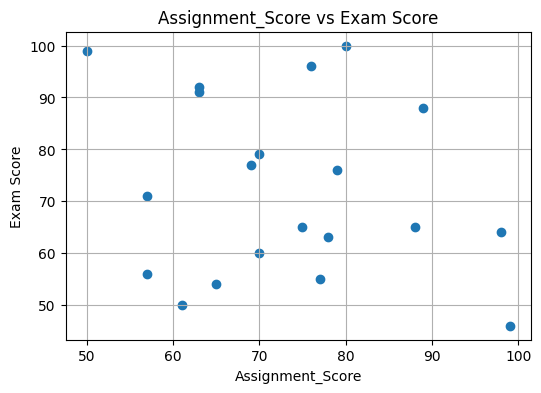

In [8]:
# Scatter Plot

plt.figure(figsize=(6,4))
plt.scatter(df[strongest], df["Exam_Score"])
plt.title(f"{strongest} vs Exam Score")
plt.xlabel(strongest)
plt.ylabel("Exam Score")
plt.grid(True)
plt.show()

In [9]:
total_students = len(df)

pass_probability = (df["Exam_Score"] >= 50).sum() / total_students
score80_probability = (df["Exam_Score"] >= 80).sum() / total_students
study5_probability = (df["Study_Hours"] > 5).sum() / total_students

print(f"Probability of Passing (Score ≥50): {pass_probability:.2%}")
print(f"Probability of Score ≥80: {score80_probability:.2%}")
print(f"Probability of Studying >5 Hours: {study5_probability:.2%}")

Probability of Passing (Score ≥50): 95.00%
Probability of Score ≥80: 30.00%
Probability of Studying >5 Hours: 45.00%


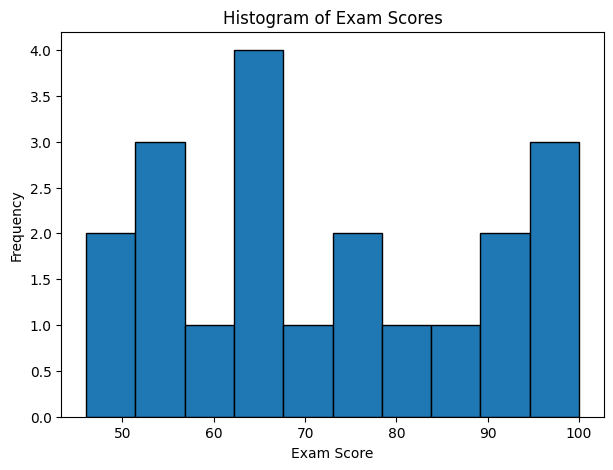

In [10]:
plt.figure(figsize=(7,5))
plt.hist(df["Exam_Score"], bins=10, edgecolor="black")
plt.title("Histogram of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

In [11]:
# Calculate Z-scores

df["Z_Score"] = stats.zscore(df["Exam_Score"])

outliers_z = df[np.abs(df["Z_Score"]) > 2]

print("Students more than 2 standard deviations from the mean:")

if outliers_z.empty:
    print("No students found.")
else:
    print(outliers_z)


Students more than 2 standard deviations from the mean:
No students found.


In [12]:
# Outlier Detection

IQR = Q3 - Q1

Lower_Bound = Q1 - 1.5 * IQR
Upper_Bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {Lower_Bound}")
print(f"Upper Bound: {Upper_Bound}")

outliers_iqr = df[
    (df["Exam_Score"] < Lower_Bound) |
    (df["Exam_Score"] > Upper_Bound)
]

print("\nOutliers using IQR:")

if outliers_iqr.empty:
    print("No outliers detected.")
else:
    print(outliers_iqr)

Lower Bound: 14.375
Upper Bound: 133.375

Outliers using IQR:
No outliers detected.


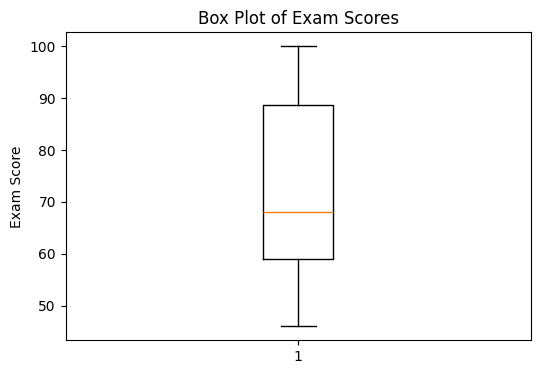

In [13]:
# Box Plot

plt.figure(figsize=(6,4))
plt.boxplot(df["Exam_Score"])
plt.title("Box Plot of Exam Scores")
plt.ylabel("Exam Score")
plt.show()

In [14]:
# Final Report

print("1. Statistical Summary")
print(f"Mean: {mean:.2f}")
print(f"Median: {median}")
print(f"Mode: {mode}")
print(f"Standard Deviation: {std_dev:.2f}")

print("\n2. Strongest Factor Associated with Exam Scores")
print(f"{strongest} (Correlation = {correlations[strongest]:.3f})")

print("\n3. Probability of Passing")
print(f"{pass_probability:.2%}")

print("\n4. Outliers Detected")
if outliers_iqr.empty:
    print("No outliers detected.")
else:
    print(outliers_iqr)

print("\n5. Recommendations")
print("- Encourage students to maintain regular study habits.")
print("- Provide extra academic support for lower-performing students.")

1. Statistical Summary
Mean: 72.35
Median: 68.0
Mode: 65
Standard Deviation: 17.18

2. Strongest Factor Associated with Exam Scores
Assignment_Score (Correlation = -0.205)

3. Probability of Passing
95.00%

4. Outliers Detected
No outliers detected.

5. Recommendations
- Encourage students to maintain regular study habits.
- Provide extra academic support for lower-performing students.
